In [39]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline
import warnings
warnings.filterwarnings('ignore'
)


In [40]:
df = pd.read_csv('data/stud.csv')

In [41]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [42]:
df.shape

(1000, 8)

Data Checks to perform

1. Check Missing values

2. Check Duplicates

3. Check data type
4. Check the number of unique values of each column
5. Check statistics of data set
6. Check various categories present in the different categorical column

### Check missing values

In [43]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [44]:
df.duplicated().sum()

0

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [46]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [47]:
## stats
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Insights


>From above description of rumerical data, all means are very close to each other - between 66 and 68.05;

> All standard deviations are also close - between 14.6 and 15.19;

> While there is a minimum score 0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

## Exploring Data


In [48]:
## define numerical & categorical columns 

num_feature = [feature for feature in df.columns if df[feature].dtype != 'O']
cat_feature = [feature for feature in df.columns if df[feature].dtype == 'O']



print('we have {} numerical features :{}'.format(len(num_feature),num_feature))
print('we have {} categorical features :{}'.format(len(cat_feature),cat_feature))


we have 3 numerical features :['math_score', 'reading_score', 'writing_score']
we have 5 categorical features :['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


### Adding a new columns for "total score" and average

In [51]:
df['total_score'] = df['math_score']+df['reading_score']+df['writing_score']
df['Average_score'] = df['total_score']/3

In [52]:
df

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,Average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333
...,...,...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95,282,94.000000
996,male,group C,high school,free/reduced,none,62,55,55,172,57.333333
997,female,group C,high school,free/reduced,completed,59,71,65,195,65.000000
998,female,group D,some college,standard,completed,68,78,77,223,74.333333


In [65]:
reading_full = df[df['reading_score'] == 100]
print('number of students with full marks in Reading',len(reading_full))

writing_full = df[df['writing_score'] == 100]
print('number of students with full marks in writing',len(writing_full))

math_full = df[df['math_score'] == 100]
print('number of students with full marks in Maths',len(math_full))

number of students with full marks in Reading 17
number of students with full marks in writing 14
number of students with full marks in Maths 7


In [68]:
reading_less_20 = df[df['reading_score'] <= 20]
print('number of students with <=20 marks in Reading',len(reading_less_20))

writing_less_20 = df[df['writing_score'] <= 20]
print('number of students with <=20  marks in writing',len(writing_less_20))

math_less_20 = df[df['math_score'] <= 20]
print('number of students with <=20 marks in Maths',len(math_less_20))

number of students with <=20 marks in Reading 1
number of students with <=20  marks in writing 3
number of students with <=20 marks in Maths 4


### Insights from the above code:
you got to know about the creamy and dull (strictly wrt marks) students of class


## Exploring Data (Visualization)

### histograms kde

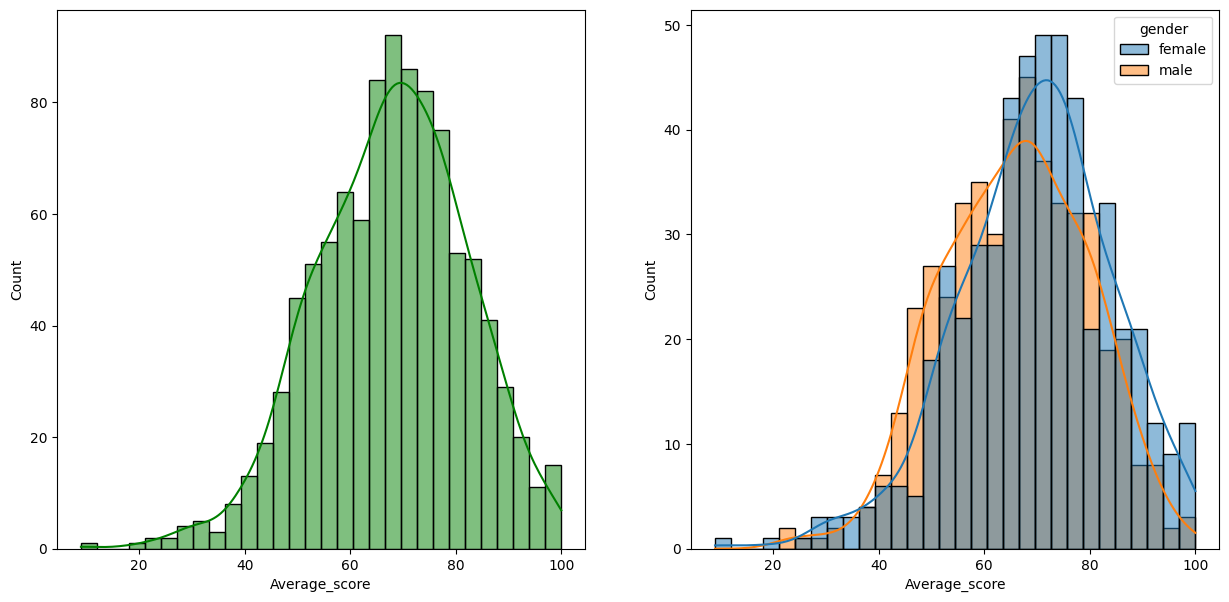

In [71]:
### 4.1.1 Histogram & KDE

fig,axs = plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='Average_score',bins = 30,kde = True,color='g')

plt.subplot(122)

sns.histplot(data=df,x='Average_score',bins = 30,kde = True,hue='gender')
plt.show()

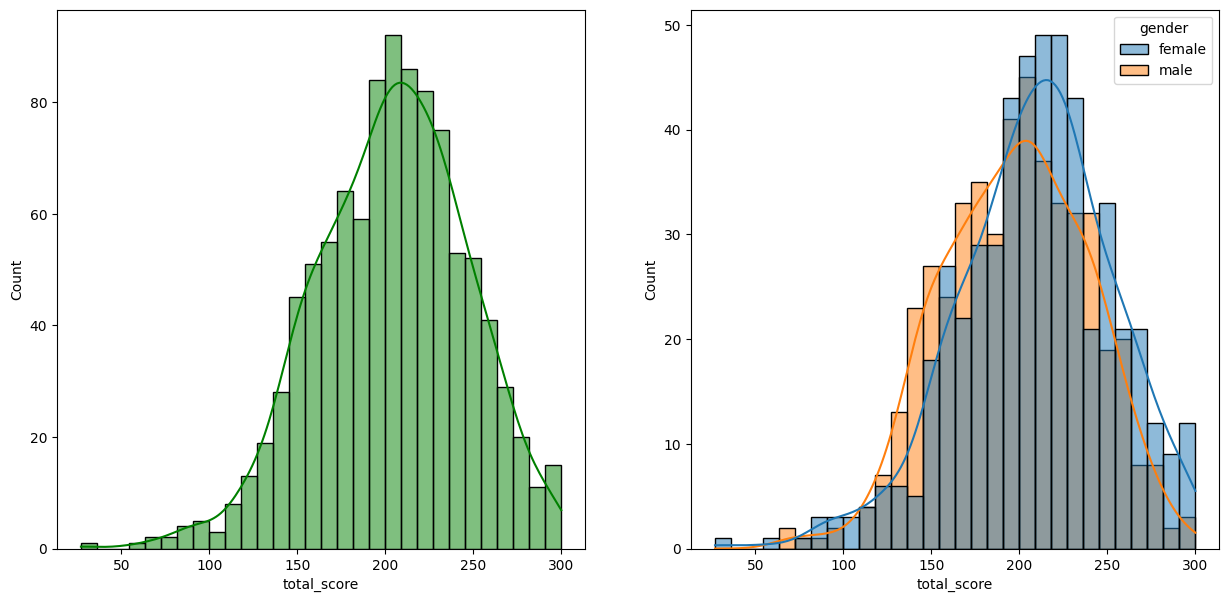

In [72]:
### 4.1.1 Histogram & KDE

fig,axs = plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='total_score',bins = 30,kde = True,color='g')

plt.subplot(122)

sns.histplot(data=df,x='total_score',bins = 30,kde = True,hue='gender')
plt.show()